# BoostFL-IoT on BoT-IoT (IID)

## 1. Imports and configuration

In [14]:
import copy
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [15]:
NUM_CLIENTS = 10
NUM_PARTITIONS = 10
NUM_ROUNDS = 15
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-3
SERVER_LR = 1.0

EPSILON = 1e-8
MIN_ALPHA = 0.1
MAX_ALPHA = 10.0

## 2. Data loading (BoT-IoT)

In [16]:
DATA_PATH = "../../data/Bot-IoT.csv"


def load_botiot(file_path, target_column, test_size=0.2, random_state=SEED):
    df = pd.read_csv(file_path).drop_duplicates()
    df = df.dropna(subset=[target_column])

    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        if df[col].isnull().any():
            mode = df[col].mode()
            df[col] = df[col].fillna(mode[0] if not mode.empty else "Unknown")

    y = df[target_column].astype(str).str.strip()
    cols_to_drop = [
        "category", "subcategory ", "attack",
        "pkSeqID", "saddr", "daddr", "soui", "doui",
        "sco", "dco", "smac", "dmac",
    ]
    X = df.drop(columns=cols_to_drop, errors="ignore").copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y,
    )

    non_numeric = list(
        set(X_train.select_dtypes(exclude=[np.number]).columns)
        | set(X_test.select_dtypes(exclude=[np.number]).columns)
    )
    for col in non_numeric:
        le = LabelEncoder()
        le.fit(X_train[col].astype(str))
        mapping = {c: i for i, c in enumerate(le.classes_)}
        X_train[col] = X_train[col].astype(str).map(mapping).fillna(-1).astype(int)
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)

    def safe_numeric(d):
        d = d.apply(lambda c: c.map(lambda v: str(v).strip() if isinstance(v, str) else v))
        d = d.apply(pd.to_numeric, errors="coerce")
        return d.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train = safe_numeric(X_train)
    X_test = safe_numeric(X_test)

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train.values)
    y_test_enc = label_encoder.transform(y_test.values)
    class_names = list(label_encoder.classes_)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train.values.astype(np.float64))
    X_test_s = scaler.transform(X_test.values.astype(np.float64))

    train_ds = TensorDataset(torch.from_numpy(X_train_s).float(),
                             torch.from_numpy(y_train_enc).long())
    test_ds = TensorDataset(torch.from_numpy(X_test_s).float(),
                            torch.from_numpy(y_test_enc).long())
    return train_ds, test_ds, class_names, len(class_names), X_train_s.shape[1]

In [17]:
def to_binary(train_ds, test_ds, class_names, normal_name="Normal"):
    """Collapse the multiclass task to Normal vs Attack (0 = Normal, 1 = Attack)."""
    names = [str(c).strip() for c in class_names]
    normal_id = names.index(normal_name) if normal_name in names else 0

    def convert(ds):
        X = ds.tensors[0]
        y = ds.tensors[1]
        y_bin = (y != normal_id).long()
        return TensorDataset(X, y_bin)

    return convert(train_ds), convert(test_ds), ["Normal", "Attack"], 2

## 3. IID partitioning

In [18]:
def partition_iid(dataset, num_partitions, num_classes, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    idx_by_class = [np.where(labels == c)[0].tolist() for c in range(num_classes)]
    partitions = [[] for _ in range(num_partitions)]
    for c in range(num_classes):
        idx = idx_by_class[c]
        rng.shuffle(idx)
        per = len(idx) // num_partitions
        rem = len(idx) % num_partitions
        start = 0
        for p in range(num_partitions):
            extra = 1 if p < rem else 0
            end = start + per + extra
            partitions[p].extend(idx[start:end])
            start = end
    for p in range(num_partitions):
        rng.shuffle(partitions[p])
    return partitions

## 4. Weak learner and residual loss

In [19]:
class WeakLearner(nn.Module):
    """Shallow MLP weak learner."""
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 50)
        self.fc2 = nn.Linear(50, 25)
        self.fc3 = nn.Linear(25, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class ResidualLoss(nn.Module):
    """Smooth-L1 loss between weak-learner output and ensemble residual."""
    def forward(self, predictions, residuals):
        return F.smooth_l1_loss(predictions, residuals)

## 5. Global boosting ensemble

In [20]:
class Ensemble:
    """Global boosting ensemble F_t = f0 + sum_i (alpha_i / sum alpha) h_i."""
    def __init__(self, f0, input_dim, num_classes, device):
        self.f0 = f0.to(device)
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.device = device
        self.learners = []
        self.alphas = []

    def add_learner(self, params, alpha):
        m = WeakLearner(self.input_dim, self.num_classes).to(self.device)
        sd = m.state_dict()
        new_sd = {k: (torch.tensor(v) if isinstance(v, np.ndarray) else v).to(self.device)
                  for k, v in zip(sd.keys(), params)}
        m.load_state_dict(new_sd)
        m.eval()
        self.learners.append(m)
        self.alphas.append(alpha)

    @torch.no_grad()
    def predict(self, x):
        out = self.f0.unsqueeze(0).expand(x.size(0), -1).clone()
        if self.learners and self.alphas:
            total = sum(self.alphas)
            if total > EPSILON:
                acc = torch.zeros_like(out)
                for m, a in zip(self.learners, self.alphas):
                    acc += (a / total) * m(x)
                out = out + acc
        return out

    def info(self):
        return {"num_learners": len(self.learners)}

## 6. Client local update

In [21]:
def local_update(global_params, ensemble, partition, train_dataset, input_dim, num_classes):
    """One client runs E local epochs on residuals. Returns (params, n, alpha)."""
    loader = DataLoader(Subset(train_dataset, partition),
                        batch_size=BATCH_SIZE, shuffle=True)

    net = WeakLearner(input_dim, num_classes).to(DEVICE)
    sd = net.state_dict()
    net.load_state_dict({k: torch.tensor(v).to(DEVICE)
                         for k, v in zip(sd.keys(), global_params)})
    net.train()

    optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    residual_loss_fn = ResidualLoss()

    total_loss, n_batches = 0.0, 0
    for _ in range(EPOCHS):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = net(xb)
            with torch.no_grad():
                ens_probs = torch.softmax(ensemble.predict(xb), dim=1)
                y_oh = torch.zeros(yb.size(0), num_classes, device=DEVICE)
                y_oh.scatter_(1, yb.unsqueeze(1), 1)
                residuals = y_oh - ens_probs
            loss = residual_loss_fn(logits, residuals)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1

    avg_loss = min(max(total_loss / max(n_batches, 1), EPSILON), 10.0)
    alpha = 1.0 / (1.0 + avg_loss)
    alpha = max(MIN_ALPHA, min(MAX_ALPHA, alpha))

    new_params = [v.detach().cpu().numpy() for v in net.state_dict().values()]
    return new_params, len(partition), alpha

## 7. Server aggregation

In [22]:
def aggregate(global_params, client_results):
    """Boosting-weighted aggregation of client parameter differences."""
    updates = [np.zeros_like(p) for p in global_params]
    weights = [a for (_, _, a) in client_results]
    wsum = sum(weights)
    for (params, _, _), w in zip(client_results, weights):
        for i in range(len(updates)):
            updates[i] += w * (params[i] - global_params[i])
    if wsum > EPSILON:
        updates = [(u / wsum) * SERVER_LR for u in updates]
    else:
        updates = [np.zeros_like(p) for p in global_params]
    new_global = [gp + updates[i] for i, gp in enumerate(global_params)]
    mean_alpha = float(np.mean(weights))
    return new_global, mean_alpha

## 8. Evaluation

In [23]:
@torch.no_grad()
def evaluate_ensemble(ensemble, test_dataset, average="macro"):
    loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = ensemble.predict(xb)
        y_pred.extend(torch.argmax(logits, 1).cpu().numpy())
        y_true.extend(yb.numpy())
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
    }

## 9. Federated driver

In [24]:
def run_boostfl(train_dataset, test_dataset, input_dim, num_classes,
                num_rounds=NUM_ROUNDS, average="macro", verbose=True):
    set_seed(SEED)
    partitions = partition_iid(train_dataset, NUM_PARTITIONS, num_classes)

    init_model = WeakLearner(input_dim, num_classes).to(DEVICE)
    global_params = [v.cpu().numpy() for v in init_model.state_dict().values()]
    f0 = torch.randn(num_classes, device=DEVICE) * 0.01
    ensemble = Ensemble(f0, input_dim, num_classes, DEVICE)

    history = {k: [] for k in ["round", "accuracy", "precision", "recall", "f1"]}
    for rnd in range(1, num_rounds + 1):
        client_results = []
        for cid in range(NUM_CLIENTS):
            client_results.append(
                local_update(global_params, ensemble, partitions[cid],
                             train_dataset, input_dim, num_classes)
            )
        global_params, mean_alpha = aggregate(global_params, client_results)
        ensemble.add_learner(global_params, mean_alpha)
        m = evaluate_ensemble(ensemble, test_dataset, average=average)
        history["round"].append(rnd)
        for k in ["accuracy", "precision", "recall", "f1"]:
            history[k].append(m[k])
        if verbose:
            print(f"[round {rnd:02d}] acc={m['accuracy']:.4f} f1={m['f1']:.4f} "
                  f"mean_alpha={mean_alpha:.3f}")
    final = evaluate_ensemble(ensemble, test_dataset, average=average)
    return history, final

## 10. Multiclass run

In [25]:
train_mc, test_mc, class_names_mc, num_classes_mc, input_dim = load_botiot(
    DATA_PATH, target_column="category")
print(f"Classes: {class_names_mc}")
print(f"Features: {input_dim} | Train: {len(train_mc)} | Test: {len(test_mc)}")

hist_mc, final_mc = run_boostfl(train_mc, test_mc, input_dim, num_classes_mc)
print("\nBoostFL-IoT (multiclass):")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {k}: {final_mc[k]:.4f}")

Classes: ['DDoS/DoS', 'Normal', 'Reconnaissance', 'Theft']
Features: 23 | Train: 40904 | Test: 10226
[round 01] acc=0.9852 f1=0.9766 mean_alpha=0.989
[round 02] acc=0.9929 f1=0.9878 mean_alpha=0.998
[round 03] acc=0.9939 f1=0.9889 mean_alpha=0.998
[round 04] acc=0.9941 f1=0.9891 mean_alpha=0.999
[round 05] acc=0.9944 f1=0.9893 mean_alpha=0.999
[round 06] acc=0.9948 f1=0.9897 mean_alpha=0.999
[round 07] acc=0.9947 f1=0.9900 mean_alpha=0.999
[round 08] acc=0.9948 f1=0.9911 mean_alpha=0.999
[round 09] acc=0.9948 f1=0.9915 mean_alpha=0.999
[round 10] acc=0.9949 f1=0.9916 mean_alpha=0.999
[round 11] acc=0.9950 f1=0.9920 mean_alpha=0.999
[round 12] acc=0.9950 f1=0.9920 mean_alpha=0.999
[round 13] acc=0.9952 f1=0.9922 mean_alpha=0.999
[round 14] acc=0.9953 f1=0.9923 mean_alpha=0.999
[round 15] acc=0.9954 f1=0.9924 mean_alpha=0.999

BoostFL-IoT (multiclass):
  accuracy: 0.9954
  precision: 0.9923
  recall: 0.9925
  f1: 0.9924


## 11. Binary run

In [26]:
train_bin, test_bin, class_names_bin, num_classes_bin = to_binary(
    train_mc, test_mc, class_names_mc)

hist_bin, final_bin = run_boostfl(
    train_bin, test_bin, input_dim, num_classes_bin, average="binary")
print("\nBoostFL-IoT (binary):")
for k in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {k}: {final_bin[k]:.4f}")

[round 01] acc=0.9863 f1=0.9915 mean_alpha=0.986
[round 02] acc=0.9939 f1=0.9963 mean_alpha=0.996
[round 03] acc=0.9950 f1=0.9969 mean_alpha=0.997
[round 04] acc=0.9954 f1=0.9972 mean_alpha=0.998
[round 05] acc=0.9962 f1=0.9977 mean_alpha=0.998
[round 06] acc=0.9958 f1=0.9974 mean_alpha=0.998
[round 07] acc=0.9961 f1=0.9976 mean_alpha=0.998
[round 08] acc=0.9962 f1=0.9977 mean_alpha=0.998
[round 09] acc=0.9963 f1=0.9977 mean_alpha=0.998
[round 10] acc=0.9963 f1=0.9977 mean_alpha=0.998
[round 11] acc=0.9964 f1=0.9978 mean_alpha=0.998
[round 12] acc=0.9964 f1=0.9978 mean_alpha=0.998
[round 13] acc=0.9965 f1=0.9978 mean_alpha=0.998
[round 14] acc=0.9965 f1=0.9978 mean_alpha=0.998
[round 15] acc=0.9965 f1=0.9978 mean_alpha=0.998

BoostFL-IoT (binary):
  accuracy: 0.9965
  precision: 0.9983
  recall: 0.9974
  f1: 0.9978


## 12. Convergence curves (Fig. 4a)

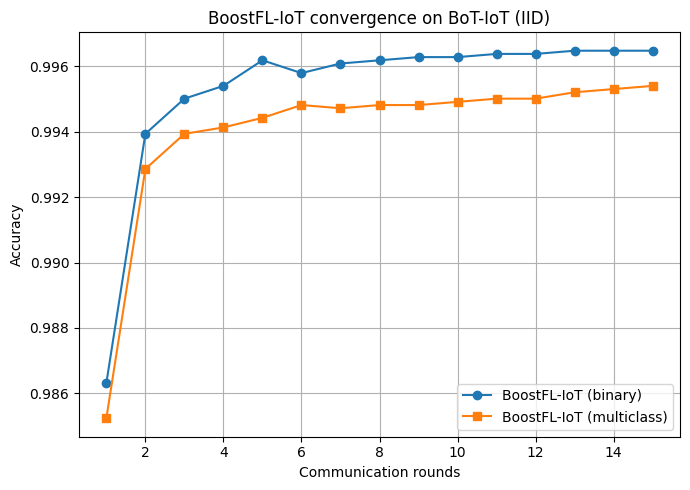

In [27]:
plt.figure(figsize=(7, 5))
plt.plot(hist_bin["round"], hist_bin["accuracy"], marker="o", label="BoostFL-IoT (binary)")
plt.plot(hist_mc["round"], hist_mc["accuracy"], marker="s", label="BoostFL-IoT (multiclass)")
plt.xlabel("Communication rounds")
plt.ylabel("Accuracy")
plt.title("BoostFL-IoT convergence on BoT-IoT (IID)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("botiot_iid_convergence.pdf", bbox_inches="tight")
plt.show()

## 13. Confusion matrices (Fig. 5)

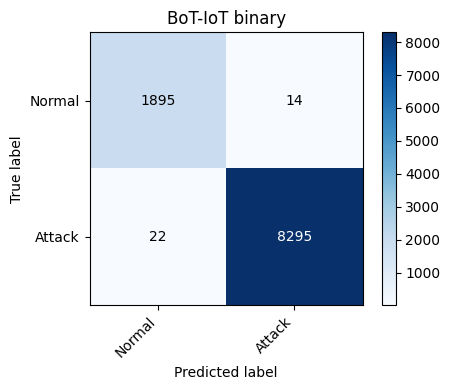

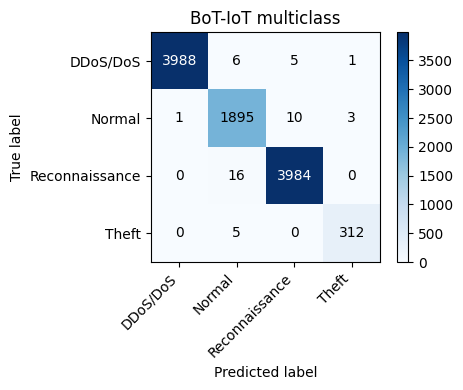

In [28]:
def plot_confusion(final, names, title, fname):
    cm = confusion_matrix(final["y_true"], final["y_pred"])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight")
    plt.show()


plot_confusion(final_bin, class_names_bin,
               "BoT-IoT binary", "botiot_confusion_binary.pdf")
plot_confusion(final_mc, class_names_mc,
               "BoT-IoT multiclass", "botiot_confusion_multiclass.pdf")